# TD-MPC2 — Visual Experiments

> **Goal:** See the two pillars of TD-MPC2 — a decoder-free latent learned for control, and MPC planning bootstrapped by a learned value — plus its stabilizers.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Decoder-free latent** | Why does a value-equivalent latent beat reconstruction on distractor-heavy input? |
| 2 | **MPC + terminal value** | How does a learned value let short-horizon planning reach far goals? |
| 3 | **MPPI planning** | How does importance-weighted sampling refine an action sequence in latent? |
| 4 | **SimNorm** | How does simplicial normalization keep the latent state bounded? |

---
**Linked theory:** [research/04-td-mpc2.md](../research/04-td-mpc2.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Decoder-free latent

**Question:** TD-MPC2 learns its latent to predict reward and value, not to reconstruct observations. Why does that help when the observation is full of task-irrelevant clutter?

Each observation has a low-variance *reward-relevant* signal and a high-variance *distractor*. We compare a reconstruction-style latent (PCA, picks max variance) against a value-equivalent latent (reward-supervised direction).

In [2]:
np.random.seed(1)

n = 1500
signal = np.random.randn(n) * 0.6          # reward-relevant, LOW variance
distractor = np.random.randn(n) * 3.0      # irrelevant, HIGH variance
obs = np.stack([signal, distractor], axis=1)
reward = signal * 2.0 + 0.1 * np.random.randn(n)   # reward depends ONLY on signal

# reconstruction proxy: top PCA direction (captures max variance)
obs_c = obs - obs.mean(0)
U, S, Vt = np.linalg.svd(obs_c, full_matrices=False)
pca_dir = Vt[0]
z_pca = obs_c @ pca_dir

# value-equivalent proxy: direction that best predicts reward (least squares)
w = np.linalg.lstsq(obs_c, reward, rcond=None)[0]
ve_dir = w / np.linalg.norm(w)
z_ve = obs_c @ ve_dir

r2 = lambda z: 1 - np.var(reward - np.polyval(np.polyfit(z, reward, 1), z)) / np.var(reward)
print(f'PCA latent points along: {pca_dir.round(2)}  -> reward R^2 = {r2(z_pca):.3f}')
print(f'value-equiv latent along: {ve_dir.round(2)} -> reward R^2 = {r2(z_ve):.3f}')

PCA latent points along: [-0.  1.]  -> reward R^2 = 0.000
value-equiv latent along: [1. 0.] -> reward R^2 = 0.993


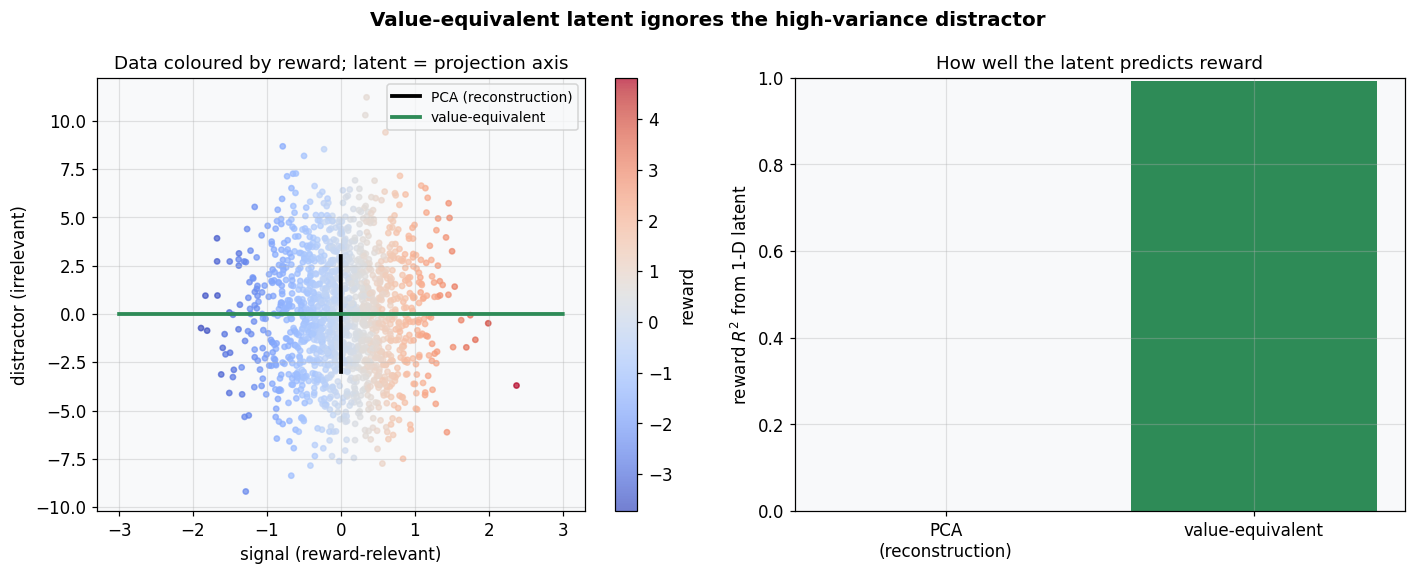

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
fig.suptitle('Value-equivalent latent ignores the high-variance distractor', fontsize=13, fontweight='bold')

ax = axes[0]
sc = ax.scatter(obs[:, 0], obs[:, 1], c=reward, cmap='coolwarm', s=12, alpha=0.7)
for d, c, lab in [(pca_dir, 'black', 'PCA (reconstruction)'), (ve_dir, 'seagreen', 'value-equivalent')]:
    ax.plot([-3 * d[0], 3 * d[0]], [-3 * d[1], 3 * d[1]], color=c, lw=2.5, label=lab)
ax.set_xlabel('signal (reward-relevant)'); ax.set_ylabel('distractor (irrelevant)')
ax.set_title('Data coloured by reward; latent = projection axis')
ax.legend(loc='upper right', fontsize=9); fig.colorbar(sc, ax=ax, label='reward')

ax2 = axes[1]
ax2.bar(['PCA\n(reconstruction)', 'value-equivalent'], [r2(z_pca), r2(z_ve)],
        color=['crimson', 'seagreen'])
ax2.set_ylabel('reward $R^2$ from 1-D latent'); ax2.set_ylim(0, 1)
ax2.set_title('How well the latent predicts reward')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The PCA axis (black) aligns with the vertical distractor — the highest-variance direction — and barely predicts reward ($R^2\approx0$). The value-equivalent axis (green) aligns with the horizontal signal and predicts reward almost perfectly.
2. **Why it looks this way:** Reconstruction (and its PCA proxy) spends the 1-D latent budget on whatever varies most, which here is the irrelevant distractor. A latent trained to predict reward instead points at the reward-relevant signal.
3. **Key takeaway:** A decoder-free, value-equivalent objective concentrates the latent on what matters for control — the same insight as MuZero, and why TD-MPC2 drops reconstruction.

---
## Experiment 2: MPC + terminal value

**Question:** Pure H-step planning is blind to rewards beyond H steps. How does bootstrapping with a learned terminal value let short-horizon planning still reach a far goal?

On a 1-D line with reward only at a distant goal, we compare planning that scores rollouts by reward alone vs reward + a terminal value (a learned distance-to-go proxy), across horizons.

In [4]:
np.random.seed(2)

GOAL = 15
def reward_fn(x):
    return 1.0 if x == GOAL else 0.0
value_fn = lambda x: -abs(x - GOAL) * 0.1   # learned terminal value proxy (shaped toward goal)


def plan_step(x, H, use_value):
    # evaluate the 3 primitive actions by a greedy H-step lookahead
    best_a, best_score = 0, -1e9
    for a0 in (-1, 0, 1):
        xt = min(max(x + a0, 0), 30); score = reward_fn(xt)
        xr = xt
        for _ in range(H - 1):                      # continue greedily toward goal sign
            step = np.sign(GOAL - xr)
            xr = min(max(xr + step, 0), 30); score += reward_fn(xr)
        if use_value:
            score += value_fn(xr)
        if score > best_score:
            best_score, best_a = score, a0
    return best_a


def run(H, use_value, steps=40):
    x = 0
    for _ in range(steps):
        x = min(max(x + plan_step(x, H, use_value), 0), 30)
        if x == GOAL:
            return 1
    return 0


Hs = [1, 2, 3, 5, 8, 12, 16]
succ_noval = [run(H, False) for H in Hs]
succ_val = [run(H, True) for H in Hs]
print('horizon       :', Hs)
print('reward only   :', succ_noval)
print('reward + value:', succ_val)

horizon       : [1, 2, 3, 5, 8, 12, 16]
reward only   : [0, 0, 0, 0, 0, 0, 1]
reward + value: [1, 1, 1, 1, 1, 1, 1]


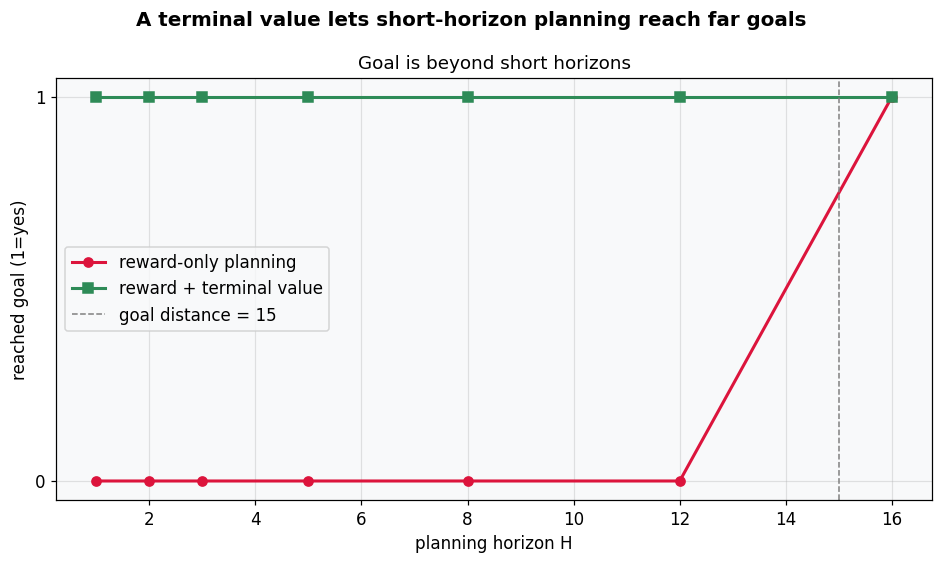

In [5]:
fig, ax = plt.subplots(figsize=(8.7, 5.2))
fig.suptitle('A terminal value lets short-horizon planning reach far goals', fontsize=13, fontweight='bold')

ax.plot(Hs, succ_noval, '-o', color='crimson', lw=2, label='reward-only planning')
ax.plot(Hs, succ_val, '-s', color='seagreen', lw=2, label='reward + terminal value')
ax.axvline(GOAL, color='gray', ls='--', lw=1, label=f'goal distance = {GOAL}')
ax.set_xlabel('planning horizon H'); ax.set_ylabel('reached goal (1=yes)')
ax.set_yticks([0, 1]); ax.set_title('Goal is beyond short horizons')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Reward-only planning (red) fails until the horizon is long enough to actually see the goal; reward + terminal value (green) succeeds even at horizon 1, because the value gradient points toward the goal from anywhere.
2. **Why it looks this way:** With sparse far reward, every short rollout scores zero, so reward-only planning is blind and picks arbitrarily. The learned terminal value summarizes long-term return into the planning objective, giving direction beyond the horizon.
3. **Key takeaway:** Combining MPC with a TD-learned value is the core of TD-MPC — short-horizon model accuracy plus long-horizon value reach, beating either alone.

---
## Experiment 3: MPPI planning

**Question:** TD-MPC2 plans with MPPI — sampling action sequences and updating their distribution by importance weighting. How does that refine a plan in latent?

We run MPPI to steer a latent point-mass to a target: sample action sequences, roll them out, weight by $\exp(\text{return}/\tau)$, refit the mean, repeat.

In [6]:
np.random.seed(3)

H, target, x0 = 12, np.array([2.0, 1.0]), np.array([-2.0, -1.5])
N, iters, tau, sigma = 200, 6, 0.5, 0.5


def rollout(actions):
    x = x0.copy(); traj = [x.copy()]
    for a in actions:
        x = x + a; traj.append(x.copy())
    return np.array(traj)


def ret(actions):
    traj = rollout(actions)
    return -((traj[-1] - target) ** 2).sum() - 0.01 * (actions ** 2).sum()


mean = np.zeros((H, 2))
iter_trajs = [rollout(mean)]
for _ in range(iters):
    samples = mean[None] + sigma * np.random.randn(N, H, 2)
    rets = np.array([ret(s) for s in samples])
    w = np.exp((rets - rets.max()) / tau); w /= w.sum()
    mean = (w[:, None, None] * samples).sum(0)         # importance-weighted update
    iter_trajs.append(rollout(mean))
print(f'final distance to target: {np.linalg.norm(iter_trajs[-1][-1] - target):.3f}')

final distance to target: 0.057


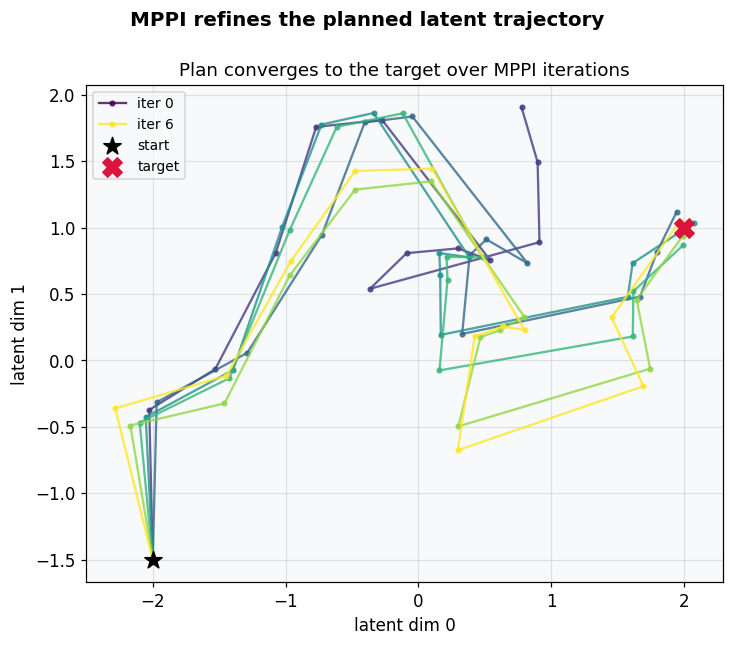

In [7]:
fig, ax = plt.subplots(figsize=(6.8, 6))
fig.suptitle('MPPI refines the planned latent trajectory', fontsize=13, fontweight='bold')

cmap = plt.cm.viridis(np.linspace(0, 1, len(iter_trajs)))
for i, (tr, c) in enumerate(zip(iter_trajs, cmap)):
    ax.plot(tr[:, 0], tr[:, 1], '-o', ms=3, color=c, alpha=0.8,
            label=f'iter {i}' if i in (0, len(iter_trajs) - 1) else None)
ax.scatter(*x0, c='black', s=140, marker='*', zorder=5, label='start')
ax.scatter(*target, c='crimson', s=160, marker='X', zorder=5, label='target')
ax.set_xlabel('latent dim 0'); ax.set_ylabel('latent dim 1')
ax.set_title('Plan converges to the target over MPPI iterations')
ax.legend(loc='upper left', fontsize=9); ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The earliest plan (dark) barely moves from the start; over MPPI iterations the planned trajectory (lighter colours) bends toward and lands on the red target.
2. **Why it looks this way:** Each iteration samples action sequences around the current mean, weights them by $\exp(\text{return}/\tau)$ so high-return plans dominate, and refits the mean toward them — a soft, gradient-free optimization of the action sequence.
3. **Key takeaway:** MPPI is the planner TD-MPC2 runs in its latent each step; combined with the terminal value from Experiment 2, it produces strong continuous-control actions.

---
## Experiment 4: SimNorm

**Question:** TD-MPC2 normalizes its latent state with SimNorm — splitting it into groups and softmax-ing each into a simplex. How does that bound the state and prevent blow-up?

We pass unbounded encoder outputs through SimNorm and compare the resulting state norms against the raw, unnormalized ones.

In [8]:
np.random.seed(4)

G, group = 8, 4          # 8 groups of 4 -> latent dim 32
scales = [0.5, 2.0, 10.0]   # encoder outputs of growing magnitude


def simnorm(z):
    z = z.reshape(-1, G, group)
    e = np.exp(z - z.max(-1, keepdims=True))
    return (e / e.sum(-1, keepdims=True)).reshape(z.shape[0], -1)


raw_norms, sim_norms = {}, {}
for s in scales:
    raw = s * np.random.randn(2000, G * group)
    raw_norms[s] = np.linalg.norm(raw, axis=1)
    sim_norms[s] = np.linalg.norm(simnorm(raw), axis=1)
print('SimNorm bounds the norm at most sqrt(G) =', round(np.sqrt(G), 2))
for s in scales:
    print(f'scale {s:>4}: raw norm ~{raw_norms[s].mean():6.2f}   SimNorm norm ~{sim_norms[s].mean():.3f}')

SimNorm bounds the norm at most sqrt(G) = 2.83
scale  0.5: raw norm ~  2.80   SimNorm norm ~1.531
scale  2.0: raw norm ~ 11.24   SimNorm norm ~2.142
scale 10.0: raw norm ~ 56.19   SimNorm norm ~2.679


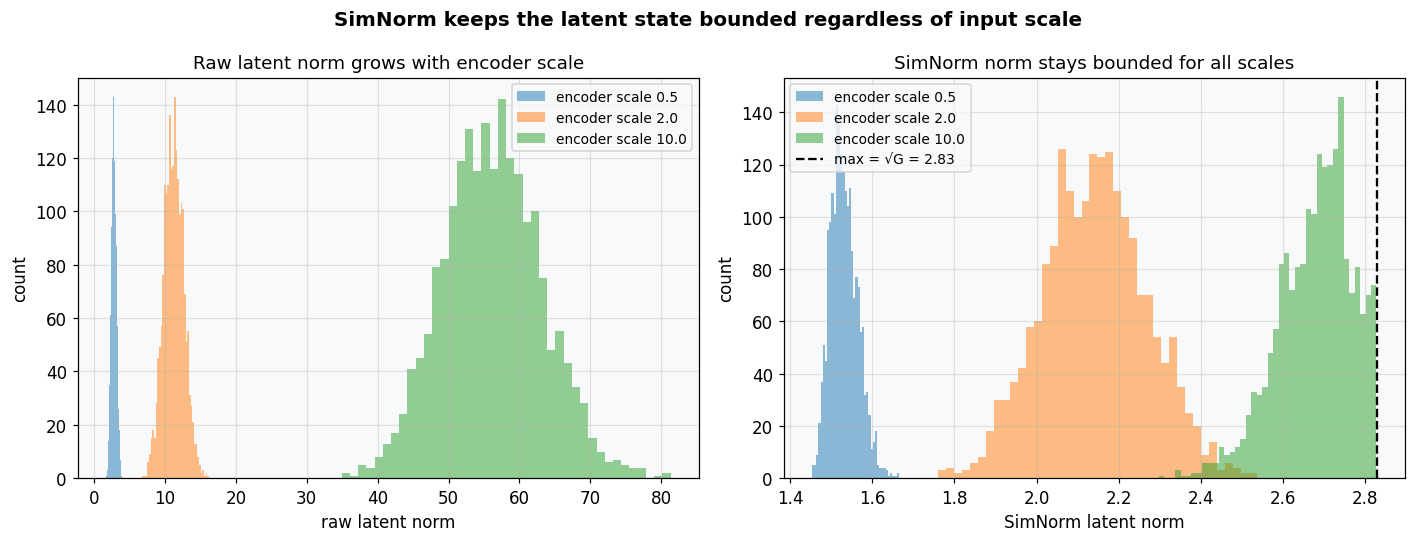

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SimNorm keeps the latent state bounded regardless of input scale', fontsize=13, fontweight='bold')

ax = axes[0]
for s in scales:
    ax.hist(raw_norms[s], bins=40, alpha=0.5, label=f'encoder scale {s}')
ax.set_xlabel('raw latent norm'); ax.set_ylabel('count')
ax.set_title('Raw latent norm grows with encoder scale')
ax.legend(fontsize=9)

ax2 = axes[1]
for s in scales:
    ax2.hist(sim_norms[s], bins=40, alpha=0.5, label=f'encoder scale {s}')
ax2.axvline(np.sqrt(G), color='black', ls='--', lw=1.5, label=f'max = √G = {np.sqrt(G):.2f}')
ax2.set_xlabel('SimNorm latent norm'); ax2.set_ylabel('count')
ax2.set_title('SimNorm norm stays bounded for all scales')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Raw latent norms grow without bound as the encoder scale increases (left), while SimNorm norms stay clustered well below √G ≈ 2.83 for every scale (right).
2. **Why it looks this way:** Softmax over each group produces a probability vector summing to 1, whose norm is at most 1; with G groups the total norm is capped at √G. The latent is forced onto a product of simplices, no matter how large the encoder output.
3. **Key takeaway:** SimNorm gives the latent a bounded, structured (simplex) geometry — preventing exploding states and helping one TD-MPC2 configuration stay stable across 100+ tasks.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Decoder-free latent | A value-equivalent latent points at reward-relevant signal; reconstruction wastes budget on high-variance distractors. |
| 2. MPC + terminal value | A learned terminal value lets short-horizon planning reach goals beyond the horizon. |
| 3. MPPI planning | Importance-weighted sampling refines an action sequence toward the target in latent. |
| 4. SimNorm | Softmax-per-group caps the latent norm at √G, keeping the state bounded across scales. |

### Connection to the broader theory

TD-MPC2 is the planning-based, decoder-free counterpart to the reconstruction-based [Dreamer](../research/01-dreamerv1.md) lineage: it learns the latent for control ([value equivalence](../../07-latent-planning/research/08-value-equivalence-muzero.md)) and acts by [MPPI](../../07-latent-planning/research/06-mppi.md) bootstrapped with a [TD value](../../07-latent-planning/research/03-value-function-in-latent.md). The next topic, **MuZero**, is the theoretical root of the decoder-free idea, set in the context of MCTS planning.